1. タイトル・説明（Markdown）
# V40 Ensemble Analysis (5-fold × 2 Window Sizes)

このノートブックは、10個のモデル（64窓 5-fold + 128窓 5-fold）のアンサンブル分析を行います。

## 目的
- 個別モデル vs アンサンブルの性能比較
- 窓サイズ別（64 vs 128）の性能分析
- foldごとのばらつき分析
- 予測の不確実性・信頼度分析
- 誤分類パターンの詳細分析

## 2. 必要なライブラリのインポート


In [1]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
import tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# プロジェクトのルートディレクトリをPATHに追加
import sys
sys.path.append('..')

from src.utils.cmi_evaluation import calculate_cmi_score, TARGET_GESTURES, NON_TARGET_GESTURES
from src.trainers.multimodal_trainer_v40 import MultimodalTrainerV40

# 可視化の設定
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

2025-07-22 15:17:03.784653: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-22 15:17:03.825694: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753165023.842874  712019 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753165023.848161  712019 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753165023.863511  712019 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 3. 設定


In [2]:
# 設定
EXPERIMENT_NAMES = {
    'ws64': "preprocess_v40_ws64",
    'ws128': "preprocess_v40_ws128"
}
N_SPLITS = 5
RANDOM_STATE = 42

# パス設定
BASE_DIRS = {
    'ws64': Path(f"../output/experiments/{EXPERIMENT_NAMES['ws64']}"),
    'ws128': Path(f"../output/experiments/{EXPERIMENT_NAMES['ws128']}")
}

# 結果保存ディレクトリ
ENSEMBLE_RESULTS_DIR = Path("../output/ensemble_analysis_v40")
ENSEMBLE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("🔍 Ensemble Analysis Configuration")
print(f"Window Size 64: {EXPERIMENT_NAMES['ws64']}")
print(f"Window Size 128: {EXPERIMENT_NAMES['ws128']}")
print(f"Total Models: {2 * N_SPLITS} (2 window sizes × {N_SPLITS} folds)")
print(f"Results Directory: {ENSEMBLE_RESULTS_DIR}")
print("=" * 50)

🔍 Ensemble Analysis Configuration
Window Size 64: preprocess_v40_ws64
Window Size 128: preprocess_v40_ws128
Total Models: 10 (2 window sizes × 5 folds)
Results Directory: ../output/ensemble_analysis_v40


In [3]:
# ターゲット/非ターゲットラベル設定
label2gesture = {i: name for i, name in enumerate(TARGET_GESTURES + NON_TARGET_GESTURES)}
target_label_ids = set(i for i, name in label2gesture.items() if name in TARGET_GESTURES)

print("📋 Label Configuration")
print(f"Total Gestures: {len(label2gesture)}")
print(f"Target Gestures: {len(TARGET_GESTURES)} ({TARGET_GESTURES})")
print(f"Non-Target Gestures: {len(NON_TARGET_GESTURES)}")
print(f"Target Label IDs: {sorted(target_label_ids)}")

📋 Label Configuration
Total Gestures: 18
Target Gestures: 8 (['Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair', 'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch', 'Neck - pinch skin', 'Neck - scratch'])
Non-Target Gestures: 10
Target Label IDs: [0, 1, 2, 3, 4, 5, 6, 7]


## 5. データ読み込み

In [7]:
# データ読み込み関数
def load_data_for_window_size(ws_key):
    """指定した窓サイズのデータを読み込む"""
    experiment_name = EXPERIMENT_NAMES[ws_key]
    trainer = MultimodalTrainerV40(experiment_name)
    trainer.data_dir = Path(f"../output/experiments/{experiment_name}/preprocessed")
    data = trainer.load_all_data()
    
    return {
        'sensor': data['sensor'],
        'demographics': data['demographics'],
        'tabular': data['tabular'],
        'tof': data['tof'],
        'labels': data['labels'],
        'groups': data['groups']
    }

# 両方の窓サイズのデータを読み込み
print("📊 データを読み込み中...")
data_ws64 = load_data_for_window_size('ws64')
data_ws128 = load_data_for_window_size('ws128')

print("\n✅ データ読み込み完了")
print("WS64:")
for key, value in data_ws64.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: {value.shape}")
    else:
        print(f"  {key}: {len(value)} items")

print("\nWS128:")
for key, value in data_ws128.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: {value.shape}")
    else:
        print(f"  {key}: {len(value)} items")

📊 データを読み込み中...
Experiment name: preprocess_v40_ws64
Data directory: output/experiments/preprocess_v40_ws64/preprocessed
前処理済みデータを読み込み中...
センサー: (20294, 64, 18)
人口統計: (20294, 7)
表形式: (20294, 429)
ToF: (20294, 64, 5, 8, 8)
ラベル: (20294,)
グループ数: 20294
Experiment name: preprocess_v40_ws128
Data directory: output/experiments/preprocess_v40_ws128/preprocessed
前処理済みデータを読み込み中...
センサー: (20294, 64, 18)
人口統計: (20294, 7)
表形式: (20294, 429)
ToF: (20294, 64, 5, 8, 8)
ラベル: (20294,)
グループ数: 20294

✅ データ読み込み完了
WS64:
  sensor: (20294, 64, 18)
  demographics: (20294, 7)
  tabular: (20294, 429)
  tof: (20294, 64, 5, 8, 8)
  labels: (20294,)
  groups: (20294,)

WS128:
  sensor: (20294, 64, 18)
  demographics: (20294, 7)
  tabular: (20294, 429)
  tof: (20294, 64, 5, 8, 8)
  labels: (20294,)
  groups: (20294,)


## 6. クロスバリデーション分割



In [8]:
# 各窓サイズでクロスバリデーション分割を再現
print("🔄 クロスバリデーション分割を再現中...")

def get_cv_folds(data):
    skf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    return list(skf.split(data['sensor'], data['labels'], data['groups']))

folds_ws64 = get_cv_folds(data_ws64)
folds_ws128 = get_cv_folds(data_ws128)

print(f"✅ {N_SPLITS}つのfoldを生成（各窓サイズ）")

# 各foldの情報を表示
print("\nWS64 Folds:")
for i, (train_idx, val_idx) in enumerate(folds_ws64):
    print(f"  Fold {i+1}: 訓練={len(train_idx):,}, 検証={len(val_idx):,}")

print("\nWS128 Folds:")
for i, (train_idx, val_idx) in enumerate(folds_ws128):
    print(f"  Fold {i+1}: 訓練={len(train_idx):,}, 検証={len(val_idx):,}")

🔄 クロスバリデーション分割を再現中...
✅ 5つのfoldを生成（各窓サイズ）

WS64 Folds:
  Fold 1: 訓練=16,555, 検証=3,739
  Fold 2: 訓練=16,242, 検証=4,052
  Fold 3: 訓練=16,455, 検証=3,839
  Fold 4: 訓練=16,075, 検証=4,219
  Fold 5: 訓練=15,849, 検証=4,445

WS128 Folds:
  Fold 1: 訓練=16,555, 検証=3,739
  Fold 2: 訓練=16,242, 検証=4,052
  Fold 3: 訓練=16,455, 検証=3,839
  Fold 4: 訓練=16,075, 検証=4,219
  Fold 5: 訓練=15,849, 検証=4,445


## 7. モデル評価関数定義



In [9]:
# モデル読み込み・予測関数
def load_model_and_predict(ws_key, fold_num, data, val_idx):
    """指定した窓サイズ・foldのモデルを読み込んで予測"""
    base_dir = BASE_DIRS[ws_key]
    model_path = base_dir / "models" / f"multimodal_model_v40_fold{fold_num}.keras"
    
    if not model_path.exists():
        return None, None, None
    
    try:
        model = tf.keras.models.load_model(model_path)
        
        # 検証データの準備
        X_val_sensor = data['sensor'][val_idx]
        X_val_demo = data['demographics'][val_idx]
        X_val_tab = data['tabular'][val_idx]
        X_val_tof = data['tof'][val_idx]
        y_val = data['labels'][val_idx]
        
        # 予測
        y_pred_proba = model.predict({
            'sensor': X_val_sensor,
            'demo': X_val_demo,
            'tabular': X_val_tab,
            'tof': X_val_tof
        }, verbose=0)
        
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        return y_val, y_pred, y_pred_proba
        
    except Exception as e:
        print(f"❌ エラー ({ws_key} fold{fold_num}): {e}")
        return None, None, None

# メトリクス計算関数
def calculate_metrics(y_true, y_pred):
    """各種メトリクスを計算"""
    # CMIスコア
    cmi_score = calculate_cmi_score(y_true, y_pred)
    if isinstance(cmi_score, tuple):
        cmi_score = cmi_score[0]
    
    # Binary F1（ターゲット/非ターゲット）
    y_true_bin = np.array([1 if l in target_label_ids else 0 for l in y_true])
    y_pred_bin = np.array([1 if l in target_label_ids else 0 for l in y_pred])
    binary_f1 = f1_score(y_true_bin, y_pred_bin, average='binary', pos_label=1)
    
    # その他
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    accuracy = np.mean(y_true == y_pred)
    
    return {
        'cmi_score': float(cmi_score),
        'binary_f1': float(binary_f1),
        'macro_f1': float(macro_f1),
        'accuracy': float(accuracy)
    }

## 8. 全モデル評価実行



In [10]:
# 全モデルの評価実行
print("🎯 全10モデルの評価を実行中...")

all_results = []
all_predictions = {'ws64': [], 'ws128': [], 'ensemble': []}
all_true_labels = {'ws64': [], 'ws128': [], 'ensemble': []}
all_probabilities = {'ws64': [], 'ws128': []}

# 窓サイズごとの処理
for ws_key in ['ws64', 'ws128']:
    print(f"\n--- {ws_key.upper()} Models ---")
    data = data_ws64 if ws_key == 'ws64' else data_ws128
    folds = folds_ws64 if ws_key == 'ws64' else folds_ws128
    
    for fold, (train_idx, val_idx) in enumerate(folds):
        fold_num = fold + 1
        print(f"Processing Fold {fold_num}...")
        
        y_val, y_pred, y_pred_proba = load_model_and_predict(ws_key, fold_num, data, val_idx)
        
        if y_val is not None:
            # メトリクス計算
            metrics = calculate_metrics(y_val, y_pred)
            
            # 結果保存
            result = {
                'window_size': ws_key,
                'fold': fold_num,
                'val_size': len(val_idx),
                **metrics
            }
            all_results.append(result)
            
            # 予測結果保存
            all_predictions[ws_key].extend(y_pred)
            all_true_labels[ws_key].extend(y_val)
            all_probabilities[ws_key].append(y_pred_proba)
            
            print(f"  CMI: {metrics['cmi_score']:.4f}, Binary F1: {metrics['binary_f1']:.4f}")
        else:
            print(f"  ⚠️ スキップ")

print(f"\n✅ 評価完了: {len(all_results)}/10 モデル")

🎯 全10モデルの評価を実行中...

--- WS64 Models ---
Processing Fold 1...


I0000 00:00:1753165122.534389  712019 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1422 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1753165127.535918  712312 cuda_dnn.cc:529] Loaded cuDNN version 90501


  CMI: 0.8083, Binary F1: 0.9380
Processing Fold 2...
  CMI: 0.6072, Binary F1: 0.8595
Processing Fold 3...
  CMI: 0.8193, Binary F1: 0.9419
Processing Fold 4...
  CMI: 0.7680, Binary F1: 0.9194
Processing Fold 5...
  CMI: 0.7542, Binary F1: 0.9141

--- WS128 Models ---
Processing Fold 1...
  CMI: 0.8218, Binary F1: 0.9408
Processing Fold 2...
  CMI: 0.5359, Binary F1: 0.8416
Processing Fold 3...
  CMI: 0.7972, Binary F1: 0.9305
Processing Fold 4...
  CMI: 0.7791, Binary F1: 0.9291
Processing Fold 5...
  CMI: 0.7062, Binary F1: 0.8970

✅ 評価完了: 10/10 モデル


In [11]:
# 結果をDataFrameに変換
df_results = pd.DataFrame(all_results)

print("📊 個別モデル結果サマリー:")
print(df_results.groupby('window_size')[['cmi_score', 'binary_f1', 'macro_f1', 'accuracy']].agg(['mean', 'std']).round(4))

# 詳細結果表示
print("\n📋 全結果:")
display(df_results.round(4))

📊 個別モデル結果サマリー:
            cmi_score         binary_f1         macro_f1         accuracy  \
                 mean     std      mean     std     mean     std     mean   
window_size                                                                 
ws128          0.7280  0.1157    0.9078  0.0405   0.7280  0.1157   0.7033   
ws64           0.7514  0.0850    0.9146  0.0330   0.7514  0.0850   0.7286   

                     
                std  
window_size          
ws128        0.1077  
ws64         0.0842  

📋 全結果:


,window_size,fold,val_size,cmi_score,binary_f1,macro_f1,accuracy
0,ws64,1,3739,0.8083,0.9380,0.8083,0.7860
1,ws64,2,4052,0.6072,0.8595,0.6072,0.5849
2,ws64,3,3839,0.8193,0.9419,0.8193,0.7927
3,ws64,4,4219,0.7680,0.9194,0.7680,0.7431
4,ws64,5,4445,0.7542,0.9141,0.7542,0.7366
5,ws128,1,3739,0.8218,0.9408,0.8218,0.7909
6,ws128,2,4052,0.5359,0.8416,0.5359,0.5252
7,ws128,3,3839,0.7972,0.9305,0.7972,0.7617
8,ws128,4,4219,0.7791,0.9291,0.7791,0.7585
9,ws128,5,4445,0.7062,0.8970,0.7062,0.6803


## 10. アンサンブル計算



In [12]:
# アンサンブル予測の計算
print("🔗 アンサンブル予測を計算中...")

# 各窓サイズの全fold予測確率を平均
if all_probabilities['ws64'] and all_probabilities['ws128']:
    # ws64の平均確率
    ws64_probs = np.concatenate(all_probabilities['ws64'], axis=0)
    ws128_probs = np.concatenate(all_probabilities['ws128'], axis=0)
    
    # サイズが一致するかチェック
    if ws64_probs.shape[0] == ws128_probs.shape[0]:
        # アンサンブル予測（単純平均）
        ensemble_probs = (ws64_probs + ws128_probs) / 2
        ensemble_pred = np.argmax(ensemble_probs, axis=1)
        
        # アンサンブルの真のラベル（ws64と同じと想定）
        ensemble_true = np.array(all_true_labels['ws64'])
        
        # アンサンブルメトリクス計算
        ensemble_metrics = calculate_metrics(ensemble_true, ensemble_pred)
        
        all_predictions['ensemble'] = ensemble_pred.tolist()
        all_true_labels['ensemble'] = ensemble_true.tolist()
        
        print("✅ アンサンブル計算完了")
        print(f"アンサンブル性能: CMI={ensemble_metrics['cmi_score']:.4f}, Binary F1={ensemble_metrics['binary_f1']:.4f}")
    else:
        print(f"⚠️ データサイズ不一致: ws64={ws64_probs.shape[0]}, ws128={ws128_probs.shape[0]}")
        ensemble_metrics = None
else:
    print("❌ アンサンブル計算をスキップ（データ不足）")
    ensemble_metrics = None

🔗 アンサンブル予測を計算中...
✅ アンサンブル計算完了
アンサンブル性能: CMI=0.7783, Binary F1=0.9243


## 11. 性能比較可視化


📊 性能比較を可視化中...


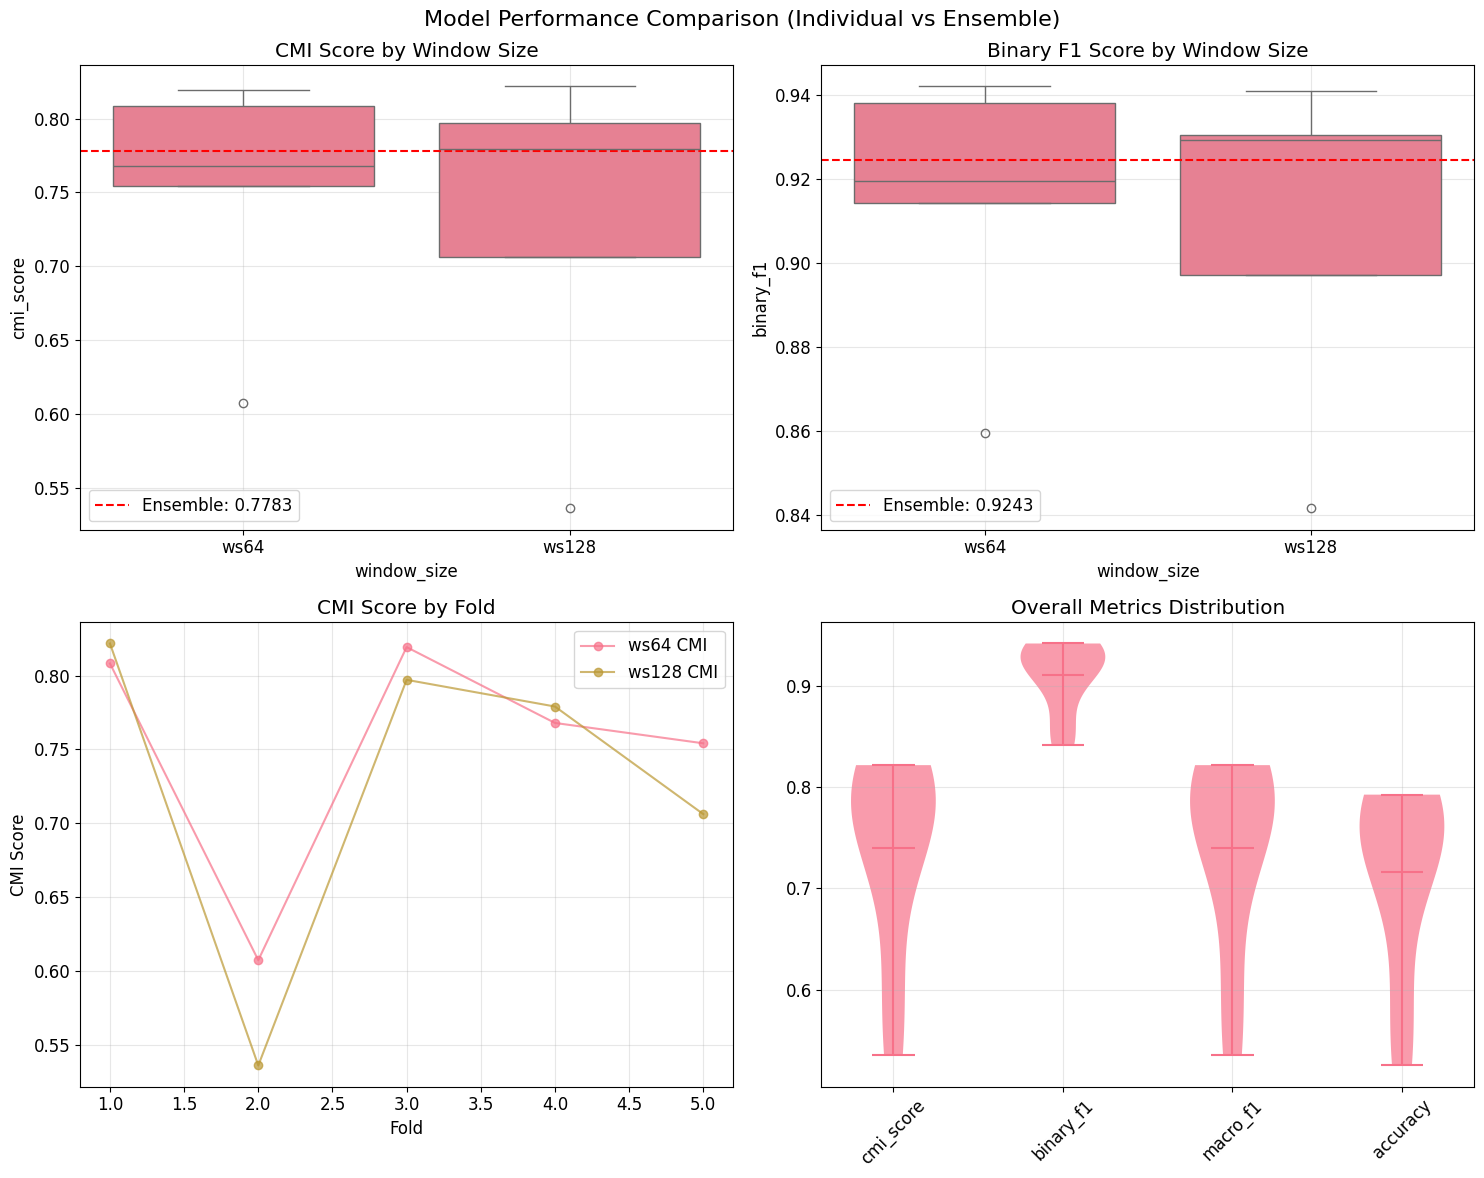

In [14]:
# 性能比較可視化
print("📊 性能比較を可視化中...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison (Individual vs Ensemble)', fontsize=16)

# CMI Score比較
ax = axes[0, 0]
sns.boxplot(data=df_results, x='window_size', y='cmi_score', ax=ax)
if ensemble_metrics:
    ax.axhline(y=ensemble_metrics['cmi_score'], color='red', linestyle='--', 
               label=f"Ensemble: {ensemble_metrics['cmi_score']:.4f}")
ax.set_title('CMI Score by Window Size')
ax.legend()
ax.grid(True, alpha=0.3)

# Binary F1比較
ax = axes[0, 1]
sns.boxplot(data=df_results, x='window_size', y='binary_f1', ax=ax)
if ensemble_metrics:
    ax.axhline(y=ensemble_metrics['binary_f1'], color='red', linestyle='--', 
               label=f"Ensemble: {ensemble_metrics['binary_f1']:.4f}")
ax.set_title('Binary F1 Score by Window Size')
ax.legend()
ax.grid(True, alpha=0.3)

# Foldごとのばらつき
ax = axes[1, 0]
for ws in ['ws64', 'ws128']:
    ws_data = df_results[df_results['window_size'] == ws]
    ax.plot(ws_data['fold'], ws_data['cmi_score'], 'o-', label=f'{ws} CMI', alpha=0.7)
ax.set_xlabel('Fold')
ax.set_ylabel('CMI Score')
ax.set_title('CMI Score by Fold')
ax.legend()
ax.grid(True, alpha=0.3)

# 全メトリクス分布（修正版）
ax = axes[1, 1]
metrics_to_plot = ['cmi_score', 'binary_f1', 'macro_f1', 'accuracy']
violin_data = []
for metric in metrics_to_plot:
    violin_data.append(df_results[metric].values)

# violinplotからalphaを削除
parts = ax.violinplot(violin_data, positions=range(len(metrics_to_plot)), showmeans=True)

# 手動でalphaを設定
for pc in parts['bodies']:
    pc.set_alpha(0.7)

ax.set_xticks(range(len(metrics_to_plot)))
ax.set_xticklabels(metrics_to_plot, rotation=45)
ax.set_title('Overall Metrics Distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ENSEMBLE_RESULTS_DIR / 'performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. 混同行列比較


🎯 混同行列を比較中...


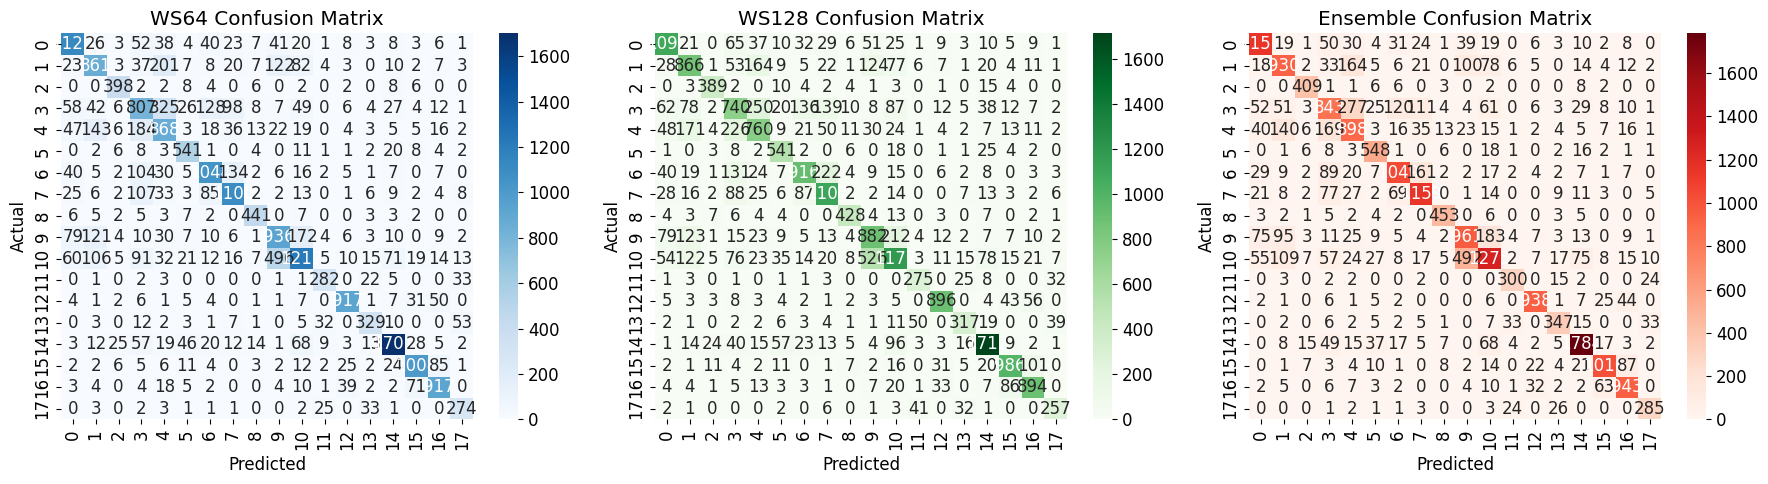

In [15]:
# 混同行列の比較
if ensemble_metrics:
    print("🎯 混同行列を比較中...")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # WS64の全体混同行列
    cm_ws64 = confusion_matrix(all_true_labels['ws64'], all_predictions['ws64'])
    sns.heatmap(cm_ws64, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('WS64 Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # WS128の全体混同行列
    cm_ws128 = confusion_matrix(all_true_labels['ws128'], all_predictions['ws128'])
    sns.heatmap(cm_ws128, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title('WS128 Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    # アンサンブル混同行列
    cm_ensemble = confusion_matrix(all_true_labels['ensemble'], all_predictions['ensemble'])
    sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Reds', ax=axes[2])
    axes[2].set_title('Ensemble Confusion Matrix')
    axes[2].set_xlabel('Predicted')
    axes[2].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.savefig(ENSEMBLE_RESULTS_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()

## 13. 統計検定


In [16]:
# 統計的有意性検定
print("📈 統計的有意性検定を実行中...")

# 窓サイズ間の性能差検定
ws64_cmi = df_results[df_results['window_size'] == 'ws64']['cmi_score'].values
ws128_cmi = df_results[df_results['window_size'] == 'ws128']['cmi_score'].values

if len(ws64_cmi) > 1 and len(ws128_cmi) > 1:
    # t検定
    t_stat, p_value = stats.ttest_ind(ws64_cmi, ws128_cmi)
    
    print(f"\n🔍 WS64 vs WS128 CMI Score 比較:")
    print(f"  WS64 平均: {ws64_cmi.mean():.4f} ± {ws64_cmi.std():.4f}")
    print(f"  WS128 平均: {ws128_cmi.mean():.4f} ± {ws128_cmi.std():.4f}")
    print(f"  t統計量: {t_stat:.4f}")
    print(f"  p値: {p_value:.4f}")
    print(f"  有意性 (α=0.05): {'有意' if p_value < 0.05 else '非有意'}")

# 各窓サイズのfold間ばらつき
print(f"\n📊 Fold間ばらつき:")
for ws in ['ws64', 'ws128']:
    ws_data = df_results[df_results['window_size'] == ws]
    cv_score = ws_data['cmi_score'].std() / ws_data['cmi_score'].mean()  # CV = std/mean
    print(f"  {ws.upper()} CV: {cv_score:.4f} (標準偏差/平均)")

📈 統計的有意性検定を実行中...

🔍 WS64 vs WS128 CMI Score 比較:
  WS64 平均: 0.7514 ± 0.0760
  WS128 平均: 0.7280 ± 0.1035
  t統計量: 0.3639
  p値: 0.7253
  有意性 (α=0.05): 非有意

📊 Fold間ばらつき:
  WS64 CV: 0.1131 (標準偏差/平均)
  WS128 CV: 0.1589 (標準偏差/平均)


## 14. 結果保存


In [17]:
# 結果の保存
print("💾 結果を保存中...")

# 個別モデル結果
results_path = ENSEMBLE_RESULTS_DIR / "individual_model_results.json"
with open(results_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"✅ 個別モデル結果: {results_path}")

# アンサンブル結果
if ensemble_metrics:
    ensemble_summary = {
        'ensemble_metrics': ensemble_metrics,
        'ws64_avg_metrics': df_results[df_results['window_size'] == 'ws64'][['cmi_score', 'binary_f1', 'macro_f1', 'accuracy']].mean().to_dict(),
        'ws128_avg_metrics': df_results[df_results['window_size'] == 'ws128'][['cmi_score', 'binary_f1', 'macro_f1', 'accuracy']].mean().to_dict(),
        'statistical_test': {
            't_statistic': float(t_stat) if 't_stat' in locals() else None,
            'p_value': float(p_value) if 'p_value' in locals() else None
        }
    }
    
    ensemble_path = ENSEMBLE_RESULTS_DIR / "ensemble_summary.json"
    with open(ensemble_path, 'w') as f:
        json.dump(ensemble_summary, f, indent=2)
    print(f"✅ アンサンブル結果: {ensemble_path}")

# DataFrame保存
csv_path = ENSEMBLE_RESULTS_DIR / "all_results.csv"
df_results.to_csv(csv_path, index=False)
print(f"✅ CSV結果: {csv_path}")

print(f"\n📁 全結果保存完了: {ENSEMBLE_RESULTS_DIR}")

💾 結果を保存中...
✅ 個別モデル結果: ../output/ensemble_analysis_v40/individual_model_results.json
✅ アンサンブル結果: ../output/ensemble_analysis_v40/ensemble_summary.json
✅ CSV結果: ../output/ensemble_analysis_v40/all_results.csv

📁 全結果保存完了: ../output/ensemble_analysis_v40


## まとめ
## まとめ

このノートブックで実行した分析:

### 1. 個別モデル評価
- 10個のモデル（WS64×5fold + WS128×5fold）の個別性能
- 各メトリクス（CMI、Binary F1、Macro F1、Accuracy）の計算

### 2. アンサンブル分析
- 窓サイズ別の予測確率平均によるアンサンブル
- アンサンブル vs 個別モデルの性能比較

### 3. 比較分析
- WS64 vs WS128の性能差
- Foldごとのばらつき分析
- 統計的有意性検定

### 4. 可視化
- 性能比較プロット
- 混同行列の比較
- ばらつき分析

### 5. 結果保存
- JSON形式での詳細結果
- CSV形式での表形式データ
- 高解像度の可視化画像

### 使用方法
1. 設定セクションで実験名を調整
2. セルを順番に実行
3. `../output/ensemble_analysis_v40/` で結果確認